In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install pykrige
!pip install geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 15.4 MB/s eta 0:00:00


# Funciones kernel implementadas

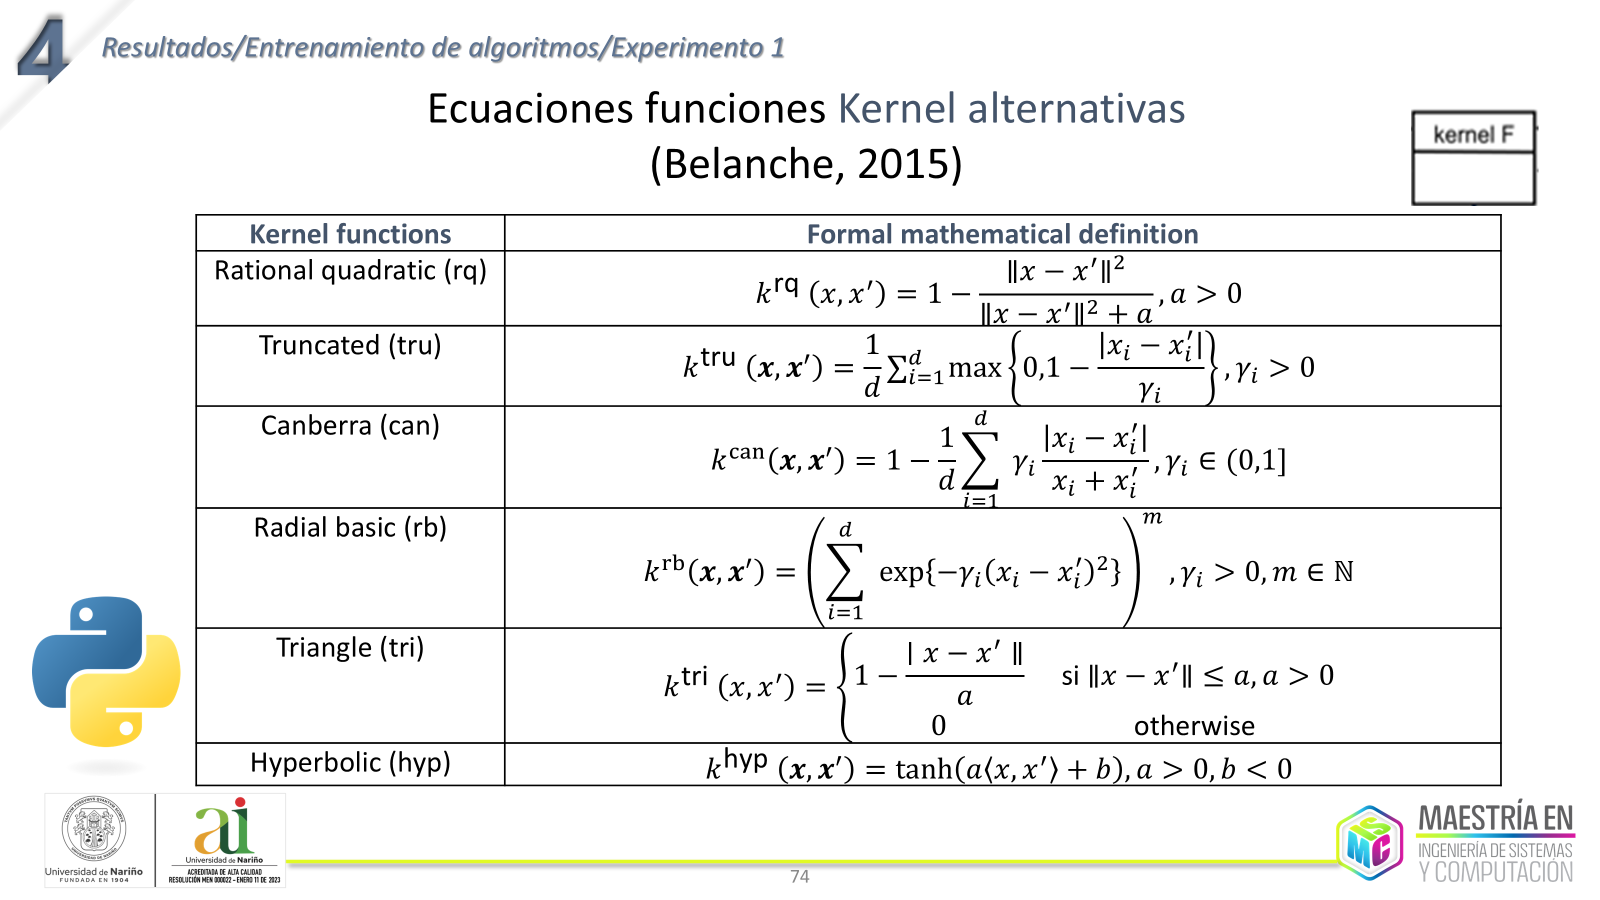

In [3]:
'''
Universidad Internacional de la RIOJA
Autor: Héctor Andrés Mora Paz (2019) V.1.0
Autor: Héctor Andrés Mora Paz (2023) V.2.0
License: GPL
This file have at Belanche Kernel functions implementation and kernel propouse
'''
import numpy as np
import numpy.linalg as la
from sklearn.metrics.pairwise import manhattan_distances
from sklearn.metrics.pairwise import chi2_kernel,additive_chi2_kernel,laplacian_kernel,sigmoid_kernel,cosine_similarity
#Kernel functions definitions are at Belanche kernel Design paper
np.seterr(divide='ignore', invalid='ignore')

#POLYNOMIAL KERNEL m E N, a>0
def polynomial(x,y, degree=3, gamma=0.01,coef0=0.0):
    m=degree
    a=gamma
    return (a*np.dot(x,y)+1)**m
#RBF gamma>0, beta E (0,2]
def mrbf(x,y, degree=3, gamma=0.01,coef0=0.0):
    beta=degree
    sm=np.sum(gamma*(x-y)**beta)
    return np.exp(-sm)

#Hyperbolic tangent kernel a0>0, b<0
def hyperbolic(x,y, degree=3, gamma=0.01,coef0=0.0):
    b=coef0
    a=gamma
    return np.tanh(a*np.dot(x,y)+b)

#Triangle a>0
def triangle(x,y, degree=3, gamma=0.01,coef0=0.0):
    a=gamma
    norm=la.norm(np.subtract(x, y))
    if norm<=a:
        return 1-norm/a
    return 0

#ANOVA gamma>0, m E N
def radial_basic(x, y, degree=3, gamma=0.01,coef0=0.0):
    m=degree
    sm=0
    sm=np.sum(np.exp(-gamma*((x-y)**2)))
    return sm**m
#Rational quadratic a>0
def rquadratic(x,y, degree=3, gamma=0.01,coef0=0.1):
    a=coef0
    norm=la.norm(np.subtract(x, y))
    return 1-(norm**2)/(norm**2+a)
#Canberra gamma E (0,1]
def canberra(x,y, degree=3, gamma=0.01,coef0=0.0):
    sm=0
    d=x.shape[0]
    r=gamma*np.abs(x-y)/(np.abs(x)+np.abs(y))
    sm=np.sum(r[~np.isnan(r)])

    return 1-sm/d
#Truncated gamma>0
def truncated(x,y, degree=3, gamma=0.01,coef0=0.0):
    sm=0
    d=x.shape[0]
    val=1-np.abs(x-y)/gamma
    sm=np.sum(val[val>0])
    return sm/d
# Nuevas funciones kernel
# Additive Chi Squared Kernel
def chi_squared(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=0
    num=(x-y)**2
    den=x+y
    sm=np.sum(num/den)
    if np.isnan(sm) or np.isinf(sm):
      sm=0
    #print(sm)
    return -sm
# chi2_kernel

def chi2(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=0
    num=(x-y)**2
    den=x+y
    sm=np.sum(num/den)
    r=np.exp(-gamma*sm)
    print(r)
    if np.isnan(r) or np.isinf(r):
      print("yea")
      r=0

    return 0
# chi2_kernel
# laplacian kernel

def laplacian(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=np.abs(x-y).sum()
    r=np.exp(-gamma*sm)
    if np.isnan(r) or np.isinf(r):
      r=0
    return r
# sigmoid
def sigmoid(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=np.tanh(gamma*x@y+coef0)

    return sm
# cosine
def cosine(x,y, degree=3, gamma=0.01,coef0=0.0):
    #print('x',x,'y',y)
    sm=(x@y)/(np.linalg.norm(x)*np.linalg.norm(y))
    if np.isnan(sm) or np.isinf(sm):
      sm=0
    return sm
#Gram Matrix
def proxy_kernel(X, Y,K, degree=3, gamma=0.01,coef0=0.0):
    if K is None:
        K=mrbf

    gram_matrix = np.zeros((X.shape[0], Y.shape[0]))
    for i, x in enumerate(X):
        for j, y in enumerate(Y):
            gram_matrix[i, j] = K(x,y, degree, gamma,coef0)
    return gram_matrix
#POLYNOMIAL
#degree=3, gamma=0.01,coef0=0.0
#------------------------------------
#Gram matrix Kernel
#POLYNOMIAL
#degree=3, gamma=0.01,coef0=0.0
def polynomial_kernel(degree, gamma):
    def pk(X,Y):
        return proxy_kernel(X,Y,K=polynomial,degree=degree,gamma=gamma)
    return pk
#MRBF
def mrbf_kernel(degree=2, gamma=0.01):
    def mrbfk(X,Y):
        return proxy_kernel(X,Y,K=mrbf,degree=degree,gamma=gamma)
    return mrbfk
#HIPERBOLIC TAN
def hyperbolic_kernel(gamma,coef0):
    def hk(X,Y):
        return proxy_kernel(X,Y,K=hyperbolic,gamma=gamma,coef0=coef0)
    return hk
#TRIANGLE
def triangle_kernel(gamma):
    def tk(X,Y):
        return proxy_kernel(X,Y,K=triangle,gamma=gamma)
    return tk
#ANOVA
def radial_basic_kernel(degree, gamma):
    def rbk(X,Y):
        return proxy_kernel(X,Y,K=radial_basic,degree=degree,gamma=gamma)
    return rbk
#RATIONAL QUADRATIC
def rquadratic_kernel(degree, gamma,coef0):
    def rqk(X,Y):
        return proxy_kernel(X,Y,K=rquadratic,degree=degree,gamma=gamma,coef0=coef0)
    return rqk
#CANBERRA
def canberra_kernel(gamma):
    def ck(X,Y):
        return proxy_kernel(X,Y,K=canberra,gamma=gamma)
    return ck
#TRUNCATED
def truncated_kernel(gamma):
    def trk(X,Y):
        return proxy_kernel(X,Y,K=truncated,gamma=gamma)
    return trk
#chi_squared
def chi_squared_kernel2(gamma):
    def csq(X,Y):
        return proxy_kernel(X,Y,K=chi_squared,gamma=gamma)
    return csq
#chi2
def chi2_kernel2(gamma):
    def c2(X,Y):
        return proxy_kernel(X,Y,K=chi2,gamma=gamma)
    return c2
#LAPLACIAN
def laplacian_kernel2(gamma):
    def lpl(X,Y):
        return proxy_kernel(X,Y,K=laplacian,gamma=gamma)
    return lpl
#SIGMOID
def sigmoid_kernel2(gamma):
    def sigm(X,Y):
        return proxy_kernel(X,Y,K=sigmoid,gamma=gamma)
    return sigm
#Cos
def cosine_kernel2():
    def cos(X,Y):
        return proxy_kernel(X,Y,K=cosine)
    return cos

#---------------------------------------
#Callable Functions
def c_polynomial_kernel(degree, gamma):
    def pk(X,Y):
        return polynomial(X,Y, degree=degree, gamma=gamma)
    return pk
#MRBF
def c_mrbf_kernel(degree=2, gamma=0.01):
    def mrbfk(X,Y):
        return mrbf(X,Y,degree=degree,gamma=gamma)
    return mrbfk
#HIPERBOLIC TAN
def c_hyperbolic_kernel(gamma,coef0):
    def hk(X,Y):
        return hyperbolic(X,Y,gamma=0.01,coef0=0.0)
    return hk
#TRIANGLE
def c_triangle_kernel(gamma):
    def tk(X,Y):
        return triangle(X,Y,gamma=gamma)
    return tk
#ANOVA
def c_radial_basic_kernel(degree, gamma):
    def rbk(X,Y):
        return radial_basic(X,Y, degree=degree, gamma=gamma)
    return rbk
#RATIONAL QUADRATIC
def c_rquadratic_kernel(degree, gamma):
    def rqk(X,Y):
        return rquadratic(X,Y, degree=degree, gamma=gamma)
    return rqk
#CANBERRA
def c_canberra_kernel(gamma):
    def ck(X,Y):
        return canberra(X,Y,gamma=gamma)
    return ck
#TRUNCATED
def c_truncated_kernel(gamma):
    def trk(X,Y):
        return truncated(X,Y,gamma=gamma)
    return trk
#CHI SQUARED
def c_chi_squared_kernel(gamma):
    def csq(X,Y):
        return chi_squared(X,Y,gamma=gamma)
    return csq
#CHI2
def c_chi2_kernel(gamma):
    def c2(X,Y):
        return chi2(X,Y,gamma=gamma)
    return c2
#LAPLACIAN
def c_laplacian_kernel(gamma):
    def lpl(X,Y):
        return laplacian(X,Y,gamma=gamma)
    return lpl
#SIGMOID
def c_sigmoid_kernel(gamma):
    def sigm(X,Y):
        return sigmoid(X,Y,gamma=gamma)
    return sigm

#COSINE
def c_cosine_kernel():
    def cos(X,Y):
        return cosine(X,Y)
    return cos

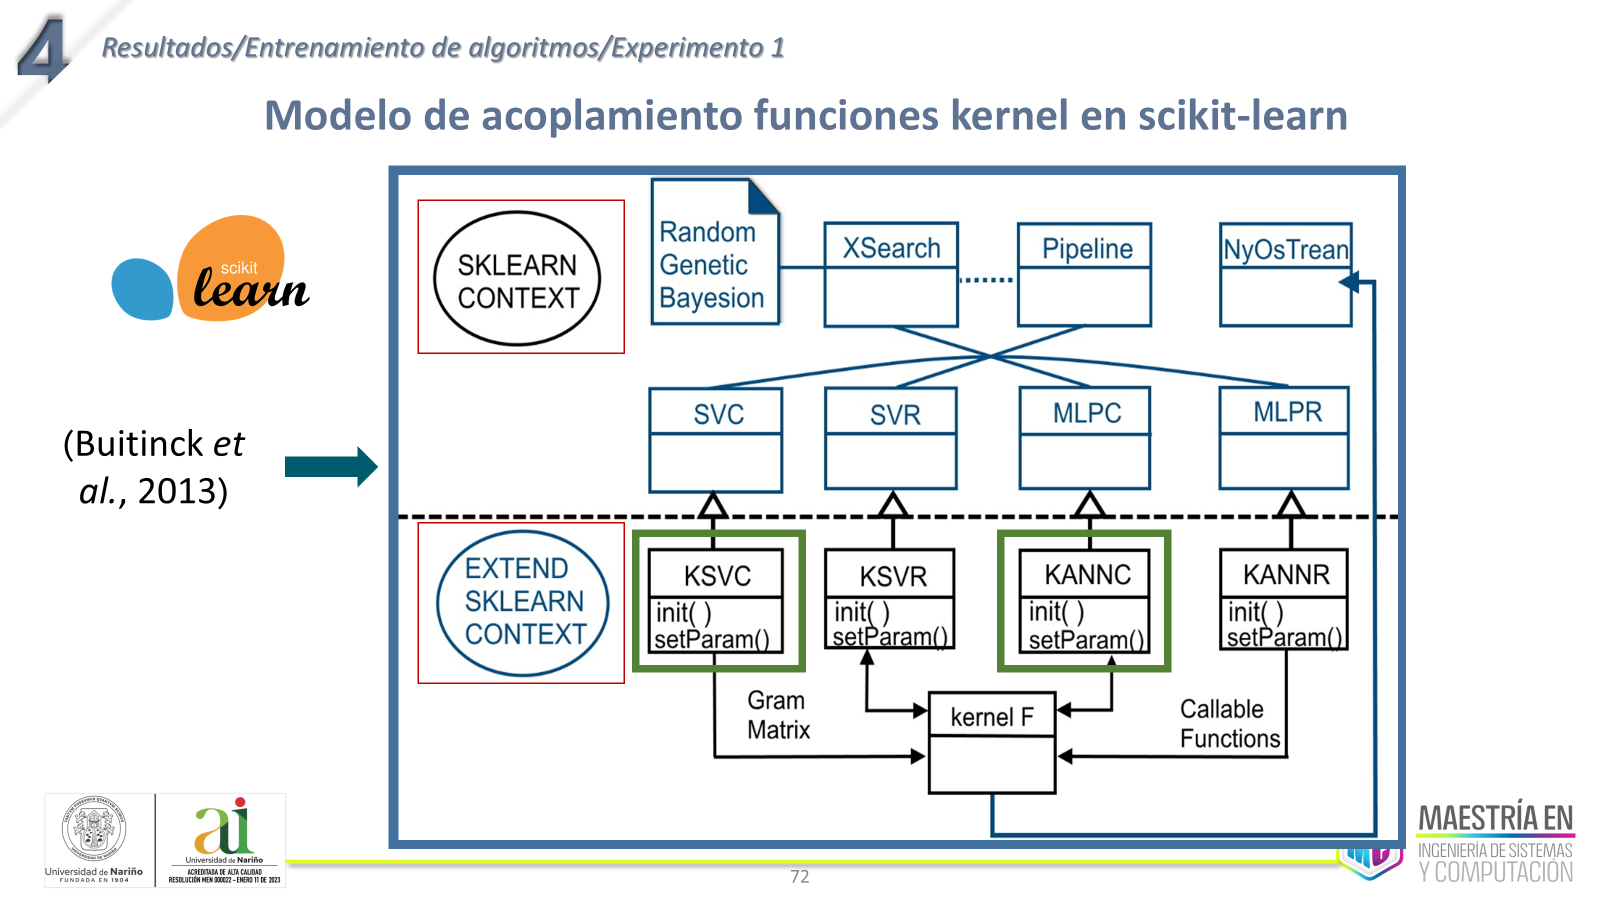

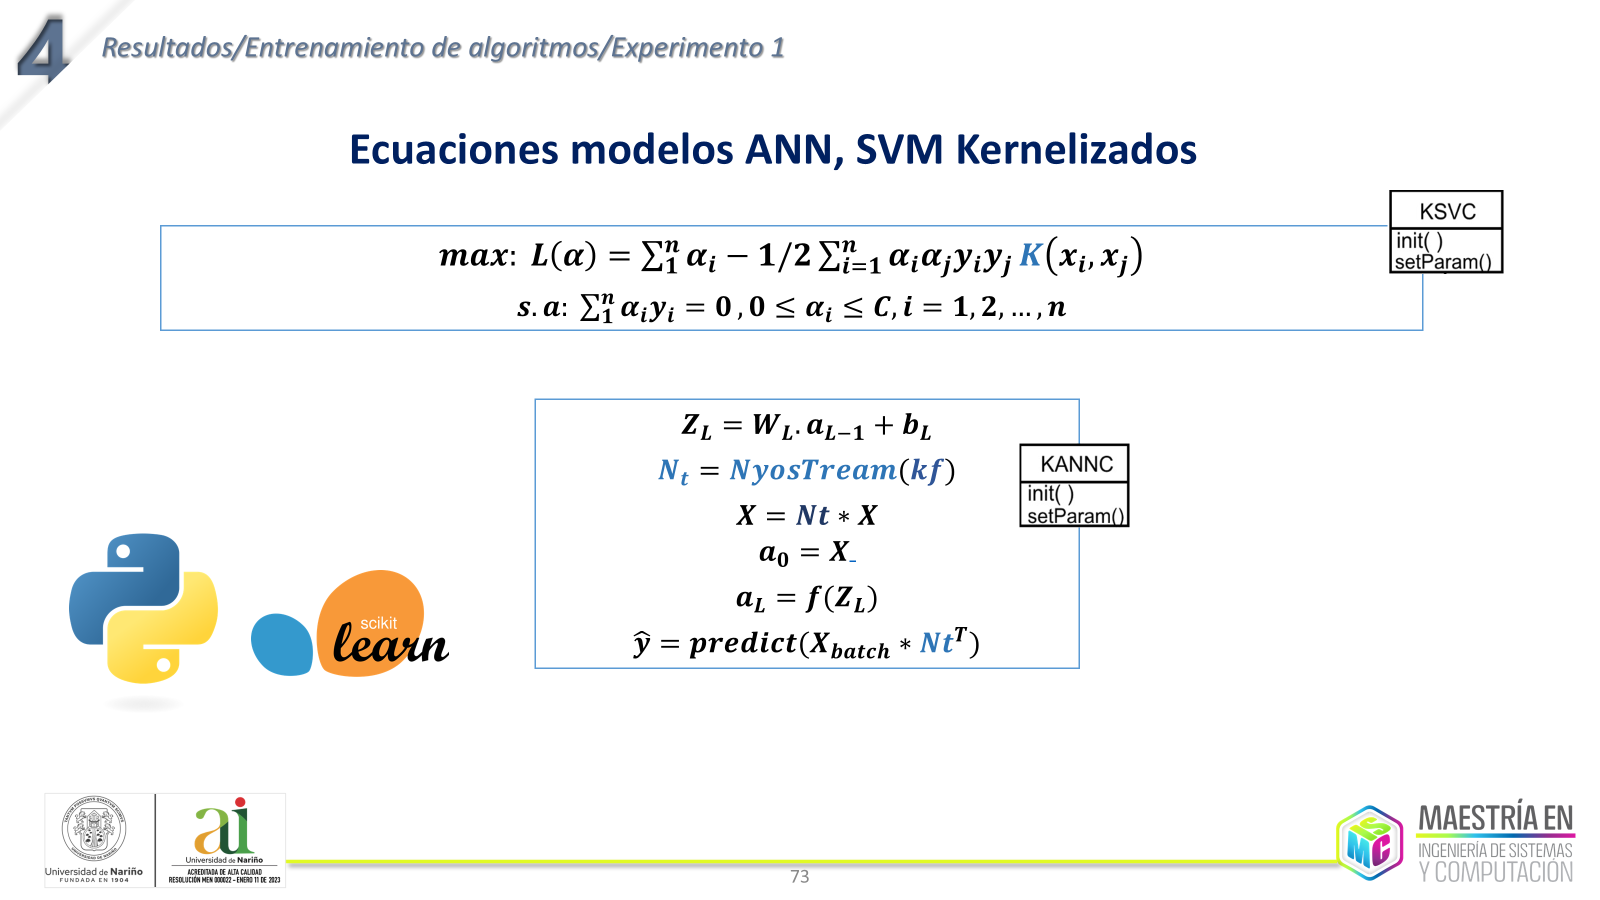

In [4]:
'''
Universidad Internacional de la RIOJA
Autor: Héctor Andrés Mora Paz (2019)
Autor: Héctor Andrés Mora Paz (2023) V.2.0
License: GPL
This file have the  Kernel Support Vector Machine (SVM)
to clasification and regresion implementation.
'''
#from .KernelUtilities import *
from sklearn.svm import SVC,SVR
from sklearn.model_selection import train_test_split
#Clasificator
class KSVC(SVC):

    def __init__(self, C=1.0, kernel='rbf', degree=2, gamma='auto',
                 coef0=0.0, shrinking=True, probability=False,
                 tol=1e-3, cache_size=200, class_weight=None,
                 verbose=False, max_iter=-1, decision_function_shape='ovr',
                 random_state=None,a=2):

        super().__init__(
        kernel=kernel, degree=degree, gamma=gamma,
        coef0=coef0, tol=tol, C=C, shrinking=shrinking,
        probability=probability, cache_size=cache_size,
        class_weight=class_weight, verbose=verbose, max_iter=max_iter,
        decision_function_shape=decision_function_shape,
        random_state=random_state)

        self.a=a

    def fit(self, X, y, sample_weight=None):

        if(self.kernel=="linear" or self.kernel== "poly" or self.kernel== "rbf"):
            super().fit(X,y)
            return self
        else:
            if(self.kernel=="mrbf"):
                self.kernel=mrbf_kernel(degree=self.degree, gamma=self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="hyperbolic"):
                self.kernel=hyperbolic_kernel(self.gamma,self.coef0)
                super().fit(X,y)
                return self
            if(self.kernel=="triangle"):
                self.kernel=triangle_kernel(self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="radial_basic"):
                self.kernel=radial_basic_kernel(self.degree, self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="rquadratic"):
                self.kernel=rquadratic_kernel(self.degree, self.gamma, self.coef0)
                super().fit(X,y)
                return self
            if(self.kernel=="can"):
                self.kernel=canberra_kernel(self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="tru"):
                self.kernel=truncated_kernel(self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="chisq"):
                print("Chisq Ok")
                self.kernel=additive_chi2_kernel
                super().fit(X,y)
                return self
            if(self.kernel=="chi2"):
                self.kernel=chi2_kernel
                super().fit(X,y)
                return self
            if(self.kernel=="laplacian"):
                self.kernel=laplacian_kernel
                super().fit(X,y)
                return self
            if(self.kernel=="sigmoid"):
                self.kernel=sigmoid_kernel
                super().fit(X,y)
                return self
            if(self.kernel=="cosine"):
                self.kernel=cosine_similarity
                super().fit(X,y)
                return self


    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
#Regressor
class KSVR(SVR):

    def __init__(self, kernel='rbf', degree=2, gamma='scale',
                 coef0=0.0, tol=1e-3, C=1.0, epsilon=0.1, shrinking=True,
                 cache_size=200, verbose=False, max_iter=-1):

        super().__init__(
            kernel=kernel, degree=degree, gamma=gamma,
            coef0=coef0, tol=tol, C=C, epsilon=epsilon, verbose=verbose,
            shrinking=shrinking, cache_size=cache_size,
            max_iter=max_iter)

    def fit(self, X, y, sample_weight=None):

        if(self.kernel=="linear" or self.kernel== "poly" or self.kernel== "rbf"):
            super().fit(X,y)
            return self
        else:
            if(self.kernel=="mrbf"):
                self.kernel=mrbf_kernel(degree=self.degree, gamma=self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="hyperbolic"):
                self.kernel=hyperbolic_kernel(self.gamma,self.coef0)
                super().fit(X,y)
                return self
            if(self.kernel=="triangle"):
                self.kernel=triangle_kernel(self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="radial_basic"):
                self.kernel=radial_basic_kernel(self.degree, self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="rquadratic"):
                self.kernel=rquadratic_kernel(self.degree, self.gamma, self.coef0)
                super().fit(X,y)
                return self
            if(self.kernel=="can"):
                self.kernel=canberra_kernel(self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="tru"):
                self.kernel=truncated_kernel(self.gamma)
                super().fit(X,y)
                return self
            if(self.kernel=="chisq"):
                self.kernel=additive_chi2_kernel
                super().fit(X,y)
                return self
            if(self.kernel=="chi2"):
                self.kernel=chi2_kernel
                super().fit(X,y)
                return self
            if(self.kernel=="laplacian"):
                self.kernel=laplacian_kernel
                super().fit(X,y)
                return self
            if(self.kernel=="sigmoid"):
                self.kernel=sigmoid_kernel
                super().fit(X,y)
                return self
            if(self.kernel=="cosine"):
                self.kernel=cosine_similarity
                super().fit(X,y)
                return self

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self

In [5]:
'''
Universidad Internacional de la RIOJA
Autor: Héctor Andrés Mora Paz (2019)
Autor: Héctor Andrés Mora Paz (2023) V.2.0
License: GPL
This file have the Kernel Artificial Neural
Network (ANN) to clasification and regresion implementation.
'''
from sklearn.neural_network import MLPClassifier,MLPRegressor
from sklearn.kernel_approximation import Nystroem
#Clasificator
class KANNC(MLPClassifier):

    def __init__(self, hidden_layer_sizes=(100,), activation="identity",
                 solver='adam', alpha=0.0001,
                 batch_size='auto', learning_rate="constant",
                 learning_rate_init=0.001, power_t=0.5, max_iter=200,
                 shuffle=True, random_state=None, tol=1e-4,
                 verbose=False, warm_start=False, momentum=0.9,
                 nesterovs_momentum=True, early_stopping=True,
                 validation_fraction=0.1, beta_1=0.9, beta_2=0.999,
                 epsilon=1e-8, n_iter_no_change=10, max_fun=15000,kernel='rbf', degree=2, gamma=0.1,
                     coef0=0.0):

        super().__init__(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=activation, solver=solver, alpha=alpha,
            batch_size=batch_size, learning_rate=learning_rate,
            learning_rate_init=learning_rate_init, power_t=power_t,
            max_iter=max_iter, shuffle=shuffle,
            random_state=random_state, tol=tol, verbose=verbose,
            warm_start=warm_start, momentum=momentum,
            nesterovs_momentum=nesterovs_momentum,
            early_stopping=early_stopping,
            validation_fraction=validation_fraction,
            beta_1=beta_1, beta_2=beta_2, epsilon=epsilon,
            n_iter_no_change=n_iter_no_change)


        self.kernel=kernel
        self.gamma=gamma
        self.degree=degree
        self.coef0=coef0


    def fit(self, X, y):
        self.feature_map_nystroem=None
        self.isfit=False
        if(self.kernel=="linear"):
            super().fit(X,y)
            return self
        else:

            if(self.kernel=="poly"):
                self.feature_map_nystroem = Nystroem(kernel=c_polynomial_kernel(degree=self.degree, gamma=self.gamma))

            if(self.kernel=="rbf"):
                self.feature_map_nystroem = Nystroem(kernel=c_mrbf_kernel(degree=self.degree, gamma=self.gamma))
            if(self.kernel=="hyperbolic"):
                self.feature_map_nystroem = Nystroem(kernel=c_hyperbolic_kernel(gamma=self.gamma,coef0=self.coef0))
            if(self.kernel=="triangle"):
                self.feature_map_nystroem = Nystroem(kernel=c_triangle_kernel(gamma=self.gamma))
            if(self.kernel=="radial_basic"):
                self.feature_map_nystroem = Nystroem(kernel=c_radial_basic_kernel(degree=self.degree, gamma=self.gamma))
            if(self.kernel=="rquadratic"):
                self.feature_map_nystroem = Nystroem(kernel=c_rquadratic_kernel(degree=self.degree, gamma=self.gamma))
            if(self.kernel=="can"):
                self.feature_map_nystroem = Nystroem(kernel=c_canberra_kernel(gamma=self.gamma))
            if(self.kernel=="tru"):
                self.feature_map_nystroem = Nystroem(kernel=c_truncated_kernel(gamma=self.gamma))
            if(self.kernel=="chisq"):
                self.feature_map_nystroem = Nystroem(kernel=c_chi_squared_kernel(gamma=self.gamma))
            if(self.kernel=="chi2"):
                self.feature_map_nystroem = Nystroem(kernel=c_chi_squared_kernel(gamma=self.gamma))
            if(self.kernel=="laplacian"):
                self.feature_map_nystroem = Nystroem(kernel=c_laplacian_kernel(gamma=self.gamma))
            if(self.kernel=="sigmoid"):
                self.feature_map_nystroem = Nystroem(kernel=c_sigmoid_kernel(gamma=self.gamma))
            if(self.kernel=="cosine"):
                self.feature_map_nystroem = Nystroem(kernel=c_cosine_kernel())



            if not self.feature_map_nystroem is None:
                data_transformed = self.feature_map_nystroem.fit_transform(X)
                super().fit(data_transformed,y)
                self.isfit=True
                return self

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    def predict(self, X):
        if self.isfit:
            X=self.mtransform(X)
        return super().predict(X)
    def mtransform(self,X):
        if not self.feature_map_nystroem is None and self.isfit:
            return self.feature_map_nystroem.transform(X)
        return X

#Regresor
class KANNR(MLPRegressor):

    def __init__(self, hidden_layer_sizes=(100,), activation="identity",
                 solver='adam', alpha=0.0001,
                 batch_size='auto', learning_rate="constant",
                 learning_rate_init=0.001,
                 power_t=0.5, max_iter=200, shuffle=True,
                 random_state=None, tol=1e-4,
                 verbose=False, warm_start=False, momentum=0.9,
                 nesterovs_momentum=True, early_stopping=False,
                 validation_fraction=0.1, beta_1=0.9, beta_2=0.999,
                 epsilon=1e-8, n_iter_no_change=10, max_fun=15000,kernel='rbf', degree=2, gamma=0.1,
                     coef0=0.0):
        super().__init__(
            hidden_layer_sizes=hidden_layer_sizes,
            activation=activation, solver=solver, alpha=alpha,
            batch_size=batch_size, learning_rate=learning_rate,
            learning_rate_init=learning_rate_init, power_t=power_t,
            max_iter=max_iter, shuffle=shuffle,
            random_state=random_state, tol=tol, verbose=verbose,
            warm_start=warm_start, momentum=momentum,
            nesterovs_momentum=nesterovs_momentum,
            early_stopping=early_stopping,
            validation_fraction=validation_fraction,
            beta_1=beta_1, beta_2=beta_2, epsilon=epsilon,
            n_iter_no_change=n_iter_no_change)


        self.kernel=kernel
        self.gamma=gamma
        self.degree=degree
        self.coef0=coef0


    def fit(self, X, y):
        self.feature_map_nystroem=None
        self.isfit=False
        if(self.kernel=="linear"):
            super().fit(X,y)
            return self
        else:

            if(self.kernel=="poly"):
                self.feature_map_nystroem = Nystroem(kernel=c_polynomial_kernel(degree=self.degree, gamma=self.gamma))

            if(self.kernel=="rbf"):
                self.feature_map_nystroem = Nystroem(kernel=c_mrbf_kernel(degree=self.degree, gamma=self.gamma))
            if(self.kernel=="hyperbolic"):
                self.feature_map_nystroem = Nystroem(kernel=c_hyperbolic_kernel(gamma=self.gamma,coef0=self.coef0))
            if(self.kernel=="triangle"):
                self.feature_map_nystroem = Nystroem(kernel=c_triangle_kernel(gamma=self.gamma))
            if(self.kernel=="radial_basic"):
                self.feature_map_nystroem = Nystroem(kernel=c_radial_basic_kernel(degree=self.degree, gamma=self.gamma))
            if(self.kernel=="rquadratic"):
                self.feature_map_nystroem = Nystroem(kernel=c_rquadratic_kernel(degree=self.degree, gamma=self.gamma))
            if(self.kernel=="can"):
                self.feature_map_nystroem = Nystroem(kernel=c_canberra_kernel(gamma=self.gamma))
            if(self.kernel=="tru"):
                self.feature_map_nystroem = Nystroem(kernel=c_truncated_kernel(gamma=self.gamma))
            if(self.kernel=="chisq"):
                self.feature_map_nystroem = Nystroem(kernel=c_chi_squared_kernel(gamma=self.gamma))
            if(self.kernel=="chi2"):
                self.feature_map_nystroem = Nystroem(kernel=c_chi_squared_kernel(gamma=self.gamma))
            if(self.kernel=="laplacian"):
                self.feature_map_nystroem = Nystroem(kernel=c_laplacian_kernel(gamma=self.gamma))
            if(self.kernel=="sigmoid"):
                self.feature_map_nystroem = Nystroem(kernel=c_sigmoid_kernel(gamma=self.gamma))
            if(self.kernel=="cosine"):
                self.feature_map_nystroem = Nystroem(kernel=c_cosine_kernel())



            if not self.feature_map_nystroem is None:
                data_transformed = self.feature_map_nystroem.fit_transform(X)
                super().fit(data_transformed,y)
                self.isfit=True
                return self

    def set_params(self, **parameters):
        for parameter, value in parameters.items():
            setattr(self, parameter, value)
        return self
    def predict(self, X):
        if self.isfit:
            X=self.mtransform(X)
        return super().predict(X)
    def mtransform(self,X):
        if not self.feature_map_nystroem is None and self.isfit:
            X=self.feature_map_nystroem.transform(X)
            return X
        return X

# Experimental Setup

In [6]:
import pykrige #biblioteca de geoestadística
import pykrige.kriging_tools as kt #herramientas para exportar e importar archivos .asc con biblioteca PyKrige
from pykrige.ok import OrdinaryKriging #Kriging Ordinario con PyKrige
import pandas as pd #biblioteca de manipulación y análisis de datos
import numpy as np #biblioteca de funciones matemáticas
import matplotlib.pyplot as plt #biblioteca de generación de gráficos

import geopandas as gpd
import matplotlib.style
import matplotlib as mpl
from shapely.geometry import MultiPoint

In [7]:
#Asegurese que las rutas correspondan a su drive
path0="/content/drive/MyDrive/Clase espejo/Conferencia UDENAR/Datasets/"
path="/content/drive/MyDrive/Clase espejo/Conferencia UDENAR/narino/"
#mpl.style.use('seaborn-whitegrid')
shapefile = gpd.read_file(path+"narino_3857.shp")
print(shapefile['geometry'])

0    MULTIPOLYGON (((-8789647.51 178242.695, -87896...
Name: geometry, dtype: geometry


<Axes: >

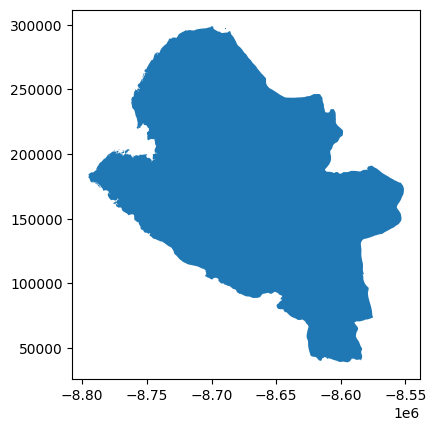

In [8]:
shapefile.plot()

In [12]:
from shapely.geometry import MultiPolygon, Polygon

def points_from_polygons(polygons):
    points = []
    for geom in polygons:
        if isinstance(geom, MultiPolygon):
            polys = list(geom.geoms) # Iterate over the individual polygons within the MultiPolygon
        elif isinstance(geom, Polygon):
            polys = [geom]
        else:
            continue # Skip if not a Polygon or MultiPolygon

        for polygon in polys:
            for point in polygon.exterior.coords:
                points.append(point)

            for interior in polygon.interiors:
                for point in interior.coords:
                    points.append(point)

    return points

In [13]:
points = points_from_polygons([shapefile['geometry'].iloc[0]])
#points = path_from_polygons(shapefile['geometry'])

#x = [point[0] for point in points]
#y = [point[1] for point in points]

In [14]:
shp=shapefile['geometry']

In [15]:
import pandas as pd

from sklearn.model_selection import  GridSearchCV, RandomizedSearchCV
#from sklearnkernels.KSVM import  KSVC,KSVR

from sklearn.model_selection import train_test_split,KFold, cross_val_score,ShuffleSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler,FunctionTransformer
import numpy as np
from time import time
from multiprocessing.pool import Pool
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from matplotlib.colors import LinearSegmentedColormap

In [16]:
dff=pd.read_csv(path0+'landsat_model.csv')
dff

,latitude,longitude,band1,band2,band3,band4,band5,band6,band7,value
0,-8789850.0,184950.0,0.105113,0.082716,0.052756,0.315520,0.132641,296.178607,0.044586,203.4
1,-8784900.0,174600.0,0.104840,0.085732,0.053527,0.271463,0.090247,295.969710,0.027292,198.3
2,-8775000.0,164700.0,0.103468,0.079147,0.048932,0.248619,0.078593,296.842689,0.022098,203.1
3,-8775000.0,169650.0,0.108849,0.090665,0.055715,0.338889,0.128227,296.123927,0.039798,199.1
4,-8775000.0,174600.0,0.096526,0.071028,0.042247,0.194788,0.054468,294.407491,0.017712,196.3
...,...,...,...,...,...,...,...,...,...,...
429,-8559900.0,154800.0,0.078925,0.066239,0.047267,0.270656,0.109293,289.724062,0.044993,237.5
430,-8559900.0,169650.0,0.063235,0.047407,0.031352,0.156130,0.061570,286.148731,0.025417,236.1
431,-8559900.0,174600.0,0.078075,0.063393,0.042869,0.230624,0.089819,290.305318,0.035603,234.4
432,-8554950.0,154800.0,0.088854,0.074230,0.049634,0.296663,0.132079,293.226199,0.048379,221.4


In [17]:
list(zip(dff.min(),dff.max()))

[(-8789850.0, -8554950.0),
 (45000.0, 294750.0),
 (0.0632353550551252, 0.12140827668879),
 (0.047406927923657, 0.10228294283352),
 (0.031073458773134, 0.0785891646003744),
 (0.156129994982684, 0.409502455050594),
 (0.0544675073321401, 0.262650167921568),
 (286.148731219607, 302.222216239513),
 (0.0177120664674527, 0.11792623003068),
 (188.5, 247.3)]

<Axes: >

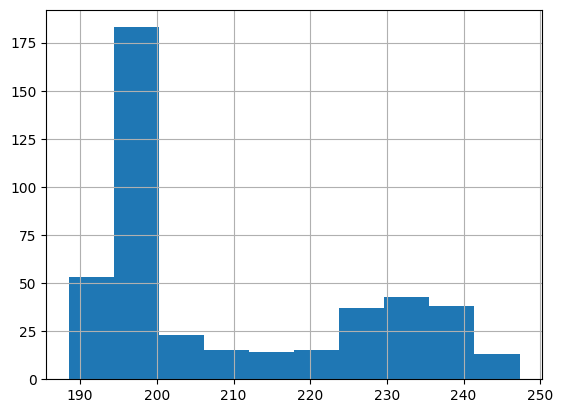

In [18]:
dff["value"].hist()

In [19]:
min_v=dff.value.min()
max_v=dff.value.max()
min_v,max_v

(188.5, 247.3)

In [20]:
dff

,latitude,longitude,band1,band2,band3,band4,band5,band6,band7,value
0,-8789850.0,184950.0,0.105113,0.082716,0.052756,0.315520,0.132641,296.178607,0.044586,203.4
1,-8784900.0,174600.0,0.104840,0.085732,0.053527,0.271463,0.090247,295.969710,0.027292,198.3
2,-8775000.0,164700.0,0.103468,0.079147,0.048932,0.248619,0.078593,296.842689,0.022098,203.1
3,-8775000.0,169650.0,0.108849,0.090665,0.055715,0.338889,0.128227,296.123927,0.039798,199.1
4,-8775000.0,174600.0,0.096526,0.071028,0.042247,0.194788,0.054468,294.407491,0.017712,196.3
...,...,...,...,...,...,...,...,...,...,...
429,-8559900.0,154800.0,0.078925,0.066239,0.047267,0.270656,0.109293,289.724062,0.044993,237.5
430,-8559900.0,169650.0,0.063235,0.047407,0.031352,0.156130,0.061570,286.148731,0.025417,236.1
431,-8559900.0,174600.0,0.078075,0.063393,0.042869,0.230624,0.089819,290.305318,0.035603,234.4
432,-8554950.0,154800.0,0.088854,0.074230,0.049634,0.296663,0.132079,293.226199,0.048379,221.4


# Experimentación

Se extraen las carácteristicas y etiquetas del conjunto de datos

In [21]:
dff.iloc[:,0:9]

,latitude,longitude,band1,band2,band3,band4,band5,band6,band7
0,-8789850.0,184950.0,0.105113,0.082716,0.052756,0.315520,0.132641,296.178607,0.044586
1,-8784900.0,174600.0,0.104840,0.085732,0.053527,0.271463,0.090247,295.969710,0.027292
2,-8775000.0,164700.0,0.103468,0.079147,0.048932,0.248619,0.078593,296.842689,0.022098
3,-8775000.0,169650.0,0.108849,0.090665,0.055715,0.338889,0.128227,296.123927,0.039798
4,-8775000.0,174600.0,0.096526,0.071028,0.042247,0.194788,0.054468,294.407491,0.017712
...,...,...,...,...,...,...,...,...,...
429,-8559900.0,154800.0,0.078925,0.066239,0.047267,0.270656,0.109293,289.724062,0.044993
430,-8559900.0,169650.0,0.063235,0.047407,0.031352,0.156130,0.061570,286.148731,0.025417
431,-8559900.0,174600.0,0.078075,0.063393,0.042869,0.230624,0.089819,290.305318,0.035603
432,-8554950.0,154800.0,0.088854,0.074230,0.049634,0.296663,0.132079,293.226199,0.048379


In [22]:
dff.iloc[:,-4],dff.iloc[:,-3],dff.iloc[:,-2],dff.iloc[:,-1]

(0      0.132641
 1      0.090247
 2      0.078593
 3      0.128227
 4      0.054468
          ...   
 429    0.109293
 430    0.061570
 431    0.089819
 432    0.132079
 433    0.129975
 Name: band5, Length: 434, dtype: float64,
 0      296.178607
 1      295.969710
 2      296.842689
 3      296.123927
 4      294.407491
           ...    
 429    289.724062
 430    286.148731
 431    290.305318
 432    293.226199
 433    290.123712
 Name: band6, Length: 434, dtype: float64,
 0      0.044586
 1      0.027292
 2      0.022098
 3      0.039798
 4      0.017712
          ...   
 429    0.044993
 430    0.025417
 431    0.035603
 432    0.048379
 433    0.050914
 Name: band7, Length: 434, dtype: float64,
 0      203.4
 1      198.3
 2      203.1
 3      199.1
 4      196.3
        ...  
 429    237.5
 430    236.1
 431    234.4
 432    221.4
 433    237.6
 Name: value, Length: 434, dtype: float64)

In [23]:
X=dff.iloc[:,0:9].to_numpy()
y=dff['value']
X.shape,y.shape

((434, 9), (434,))

### PipeLines

In [24]:
from sklearn.pipeline import Pipeline

El escalado de datos para algunos algoritmos como las SVM y la ANN favorece el aprendizaje de patrones

In [25]:
from sklearn.svm import  SVR
p_sts_ksvr = Pipeline([('sscaler', StandardScaler()), ('svr', KSVR())])
p_mms_ksvr = Pipeline([('mscaler', MinMaxScaler()), ('svr', KSVR())])
p_nms_ksvr = Pipeline([('nscaler', Normalizer()), ('svr', KSVR())])

pipes=[{"name":"SScaler","pipe":p_sts_ksvr},{"name":"MMScaler","pipe":p_mms_ksvr},{"name":"NMScaler","pipe":p_nms_ksvr}]


### Busqueda de Hiper Parámetros

In [26]:
rq_params={"svr__kernel": ['rquadratic'], "svr__C": np.logspace(0,5,10),"svr__coef0" : np.logspace(-4,4,20),"svr__gamma" : ["auto"]}
rbf_params={"svr__kernel": ['rbf'],"svr__C": np.logspace(0,5,10), "svr__gamma" : np.logspace(-4,4,20)}
tru_params={"svr__kernel": ['tru'],"svr__C": np.logspace(0,5,10), "svr__gamma" : np.logspace(-4,4,20)}
can_params={"svr__kernel": ['can'],"svr__C": np.logspace(0,5,10),"svr__gamma" : np.logspace(-4,4,20)}
rb_params={"svr__kernel": ['radial_basic'],"svr__C": np.logspace(0,5,10),"svr__gamma" : np.logspace(-4,4,20)}
tri_params={"svr__kernel": ['triangle'],"svr__C": np.logspace(0,5,10),"svr__gamma" : np.logspace(-4,4,20)}
hp_params={"svr__kernel": ['hyperbolic'],"svr__C": np.logspace(0,5,10), "svr__gamma" : np.logspace(-4,4,20)}

params=[rq_params,rbf_params,tru_params,can_params,rb_params,tri_params,hp_params]

#params=[rbf_params]

## Sintonizando

Buscando la mejor configuración para cada escalador

In [ ]:
def random_searchFit(X_train,X_test,y_train,y_test,filename):
  best_params=[]
  for index,pipe in enumerate(pipes):
    print(pipe["name"])
    for param in params:
      print(param)

      clf=RandomizedSearchCV(pipe["pipe"],param,cv=5, random_state=2025, n_jobs=-1)
      clf.fit(X_train,y_train)
      print("best tuning score",clf.best_score_)
      bes_model=clf.best_estimator_.fit(X_train,y_train)
      score=bes_model.score(X_test,y_test)
      print("best model score",score)
      print("best params",clf.best_params_)

      best_params.append({"pipe":pipe["name"],"best_params":clf.best_params_,"hpscore":clf.best_score_,"score":score, "cv_results":clf.cv_results_})


  lst_best_params=[]

  for bp in  best_params:
    mean_test_score=bp['cv_results']['mean_test_score']
    mean_fit_time=bp['cv_results']['mean_fit_time']
    mean_score_time=bp['cv_results']['mean_score_time']
    std_test_score=bp['cv_results']['std_test_score']
    std_fit_time=bp['cv_results']['std_fit_time']
    std_score_time=bp['cv_results']['std_score_time']


    i=np.argmax(mean_test_score)
    lst_best_params.append({
        'Scaler':bp['pipe'],
        'kernel':bp['best_params']['svr__kernel'],
        'mean_test_score':mean_test_score[i],
        'std_test_score':std_test_score[i],
        'mean_fit_time':mean_fit_time[i],
        'std_fit_time':std_fit_time[i],
        'mean_score_time':mean_score_time[i],
        'std_score_time':std_score_time[i],
        'best_param':bp['best_params'],
        'hpscore':bp['hpscore'],
        'score':bp['score']
        })
  df_bp=pd.DataFrame(lst_best_params)
  display(df_bp)
  df_bp.to_csv(path0+filename[0])

In [34]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2025)
#random_searchFit(X_train,X_test,y_train,y_test,['regresor_search.csv'])

# Recovery results

In [27]:
import pandas as pd

df_results=pd.read_csv(path0+'regresor_search.csv')
df_results

,Unnamed: 0,Scaler,kernel,mean_test_score,std_test_score,mean_fit_time,std_fit_time,mean_score_time,std_score_time,best_param,hpscore,score
0,0,SScaler,rquadratic,0.880593,0.023527,1.079046,0.046394,0.184746,0.008985,"{'svr__kernel': 'rquadratic', 'svr__gamma': 'a...",0.880593,0.899223
1,1,SScaler,rbf,0.889789,0.024214,0.067893,0.023924,0.008041,0.002759,"{'svr__kernel': 'rbf', 'svr__gamma': np.float6...",0.889789,0.884627
2,2,SScaler,tru,0.851626,0.035511,2.317392,0.432290,0.536121,0.101837,"{'svr__kernel': 'tru', 'svr__gamma': np.float6...",0.851626,0.840012
3,3,SScaler,can,0.848354,0.033319,2.289658,0.411942,0.604544,0.144298,"{'svr__kernel': 'can', 'svr__gamma': np.float6...",0.848354,0.826730
4,4,SScaler,radial_basic,0.907184,0.032182,1.363280,0.026973,0.347095,0.059216,"{'svr__kernel': 'radial_basic', 'svr__gamma': ...",0.907184,0.873606
5,5,SScaler,triangle,0.915111,0.016946,0.974909,0.261080,0.228292,0.056260,"{'svr__kernel': 'triangle', 'svr__gamma': np.f...",0.915111,0.908194
6,6,SScaler,hyperbolic,0.835041,0.042176,0.500873,0.015717,0.120620,0.009454,"{'svr__kernel': 'hyperbolic', 'svr__gamma': np...",0.835041,0.819612
7,7,MMScaler,rquadratic,0.888324,0.018551,0.728389,0.030105,0.181749,0.009343,"{'svr__kernel': 'rquadratic', 'svr__gamma': 'a...",0.888324,0.899135
8,8,MMScaler,rbf,0.851472,0.024248,0.013289,0.000407,0.004700,0.000166,"{'svr__kernel': 'rbf', 'svr__gamma': np.float6...",0.851472,0.870260
9,9,MMScaler,tru,0.880629,0.030911,2.043177,0.321561,0.593266,0.167151,"{'svr__kernel': 'tru', 'svr__gamma': np.float6...",0.880629,0.848432


Qué algoritmos obtuvieron un R^2 mayor a 0.9

In [28]:
df_results[df_results['score']>0.9]

,Unnamed: 0,Scaler,kernel,mean_test_score,std_test_score,mean_fit_time,std_fit_time,mean_score_time,std_score_time,best_param,hpscore,score
5,5,SScaler,triangle,0.915111,0.016946,0.974909,0.261080,0.228292,0.056260,"{'svr__kernel': 'triangle', 'svr__gamma': np.f...",0.915111,0.908194
11,11,MMScaler,radial_basic,0.904958,0.024410,1.345562,0.023846,0.323860,0.018235,"{'svr__kernel': 'radial_basic', 'svr__gamma': ...",0.904958,0.921378
12,12,MMScaler,triangle,0.920453,0.015374,0.719235,0.038927,0.173996,0.008349,"{'svr__kernel': 'triangle', 'svr__gamma': np.f...",0.920453,0.915422


In [29]:
df_results[df_results['score']>0.9].iloc[-1:,:]


,Unnamed: 0,Scaler,kernel,mean_test_score,std_test_score,mean_fit_time,std_fit_time,mean_score_time,std_score_time,best_param,hpscore,score
12,12,MMScaler,triangle,0.920453,0.015374,0.719235,0.038927,0.173996,0.008349,"{'svr__kernel': 'triangle', 'svr__gamma': np.f...",0.920453,0.915422


In [30]:
best_param=df_results[df_results['score']>0.9].iloc[-1:,:]['best_param']
best_param

,best_param
12,"{'svr__kernel': 'triangle', 'svr__gamma': np.f..."


In [ ]:
# to dict
best_param=best_param.to_dict()
best_param

# Load best model

In [31]:
svr_best=Pipeline([
    ('mscaler', MinMaxScaler()),
    ('svr', KSVR(kernel='triangle',gamma=78.47599703514607,C=7742.636826811277))
 ])

In [35]:
svr_best.fit(X_train,y_train)

Pipeline(steps=[('mscaler', MinMaxScaler()),
                ('svr',
                 KSVR(C=7742.636826811277, gamma=78.47599703514607,
                      kernel=<function triangle_kernel.<locals>.tk at 0x7f38683faf20>))])

In [36]:
svr_best.score(X_test,y_test)

0.9154220206273269

# Raster Model

In [37]:
from matplotlib.colors import LinearSegmentedColormap

In [38]:
# Graficar mapa
def draw_map(x,y,z, title="",subtitle="",units="", onlyone=False):
  mpl.style.use('default')
  # Estos colores cambiarlos según el tipo de estudio
  # Agua preferiblemente en azules
  # Vegetación en verdes
  colors = [(0, 0, 1), (0, 0.7, 0),(0, 1, 0),(0.9,1,0),(1,0.7,0),(1, 0.5, 0),(1, 0, 0) ]
  cmap_name = 'my_list'
  cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=100)
  marker_size = 5
  plt.scatter(x, y, marker_size, z, cmap=cm)
  plt.axis('equal')
  plt.title(title+"\n"+subtitle)
  cbar = plt.colorbar()
  cbar.set_label(units, labelpad=+1)
  plt.xticks([])
  plt.yticks([])
  if(onlyone):
    plt.show()

In [39]:
# Obtener una imagen desde un dataframe
def get_images(df,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  matrix_b1 = np.zeros((cols, rows))
  matrix_b2 = np.zeros((cols, rows))
  matrix_b3 = np.zeros((cols, rows))
  matrix_b4 = np.zeros((cols, rows))
  matrix_b5 = np.zeros((cols, rows))
  matrix_b6 = np.zeros((cols, rows))
  matrix_b7 = np.zeros((cols, rows))
  matrix_irradiance = np.zeros((cols, rows))

  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        matrix_b1[lon_index, lat_index] = row['band1']
        matrix_b2[lon_index, lat_index] = row['band2']
        matrix_b3[lon_index, lat_index] = row['band3']
        matrix_b4[lon_index, lat_index] = row['band4']
        matrix_b5[lon_index, lat_index] = row['band5']
        matrix_b6[lon_index, lat_index] = row['band6']
        matrix_b7[lon_index, lat_index] = row['band7']
        matrix_irradiance[lon_index, lat_index] = row['irradiance']

  satelital_image = np.stack((matrix_b1, matrix_b2, matrix_b3, matrix_b4, matrix_b5, matrix_b6, matrix_b7), axis=-1)
  return satelital_image,matrix_irradiance

def get_dataframe(df,matrix,max_lat,min_lat,max_lon,min_lon):
  rows = int(np.ceil((max_lat - min_lat) / 4950)) + 1
  cols = int(np.ceil((max_lon - min_lon) / 4950)) + 1
  lat=[]
  lon=[]
  irradiance=[]
  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_lat) / 4950))
      lon_index = int(np.floor((max_lon-row['lon']) / 4950))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        lat.append(row['lat'])
        lon.append(row['lon'])
        irradiance.append(matrix[lon_index, lat_index])

  df_result=pd.DataFrame({'latitude':lat,'longitude':lon,'irradiance':irradiance})
  return df_result

In [40]:
dff

,latitude,longitude,band1,band2,band3,band4,band5,band6,band7,value
0,-8789850.0,184950.0,0.105113,0.082716,0.052756,0.315520,0.132641,296.178607,0.044586,203.4
1,-8784900.0,174600.0,0.104840,0.085732,0.053527,0.271463,0.090247,295.969710,0.027292,198.3
2,-8775000.0,164700.0,0.103468,0.079147,0.048932,0.248619,0.078593,296.842689,0.022098,203.1
3,-8775000.0,169650.0,0.108849,0.090665,0.055715,0.338889,0.128227,296.123927,0.039798,199.1
4,-8775000.0,174600.0,0.096526,0.071028,0.042247,0.194788,0.054468,294.407491,0.017712,196.3
...,...,...,...,...,...,...,...,...,...,...
429,-8559900.0,154800.0,0.078925,0.066239,0.047267,0.270656,0.109293,289.724062,0.044993,237.5
430,-8559900.0,169650.0,0.063235,0.047407,0.031352,0.156130,0.061570,286.148731,0.025417,236.1
431,-8559900.0,174600.0,0.078075,0.063393,0.042869,0.230624,0.089819,290.305318,0.035603,234.4
432,-8554950.0,154800.0,0.088854,0.074230,0.049634,0.296663,0.132079,293.226199,0.048379,221.4


In [41]:
min_lat=dff["latitude"].min()
max_lat=dff["latitude"].max()
min_lon=dff["longitude"].min()
max_lon=dff["longitude"].max()
print(min_lat,max_lat,min_lon,max_lon)

-8789850.0 -8554950.0 45000.0 294750.0


In [42]:
path

'/content/drive/MyDrive/Clase espejo/Conferencia UDENAR/narino/'

# Grid Narinio es una malla de puntos compacta

In [43]:
dfnar=pd.read_csv(path+"gridNarinio.csv")
dfnar

,Unnamed: 0,lat,lon
0,0,-8.623484e+06,45000.0
1,1,-8.622961e+06,45000.0
2,2,-8.622438e+06,45000.0
3,3,-8.621915e+06,45000.0
4,4,-8.621392e+06,45000.0
...,...,...,...
109742,109742,-8.695681e+06,294750.0
109743,109743,-8.695158e+06,294750.0
109744,109744,-8.686787e+06,294750.0
109745,109745,-8.686264e+06,294750.0


In [44]:
Xi =dfnar.loc[:,"lat"].to_numpy()
Yi =dfnar.loc[:,"lon"].to_numpy()

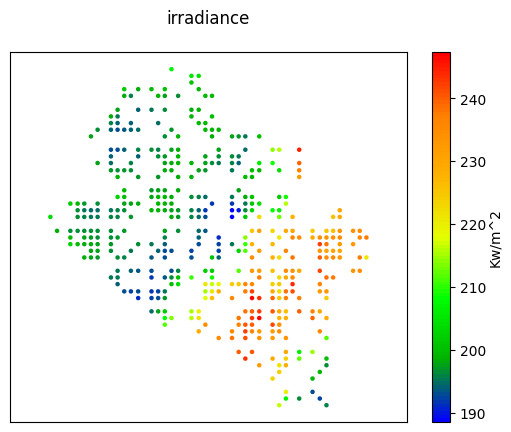

In [45]:
draw_map(dff.latitude,dff.longitude,dff.value,"irradiance","","Kw/m^2")

# Draw prediction

In [46]:
yp=svr_best.predict(X)
yp.shape

(434,)

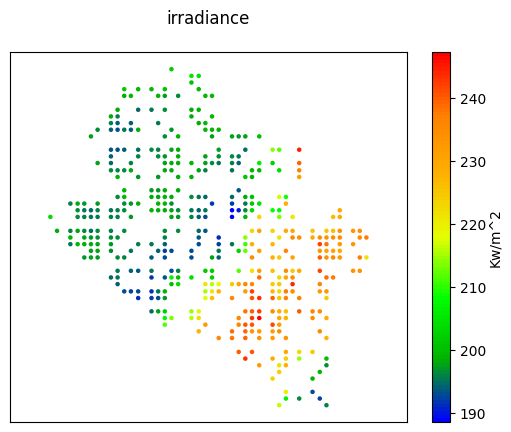

In [47]:
draw_map(dff.latitude,dff.longitude,yp,"irradiance","","Kw/m^2")

# Kriging Original

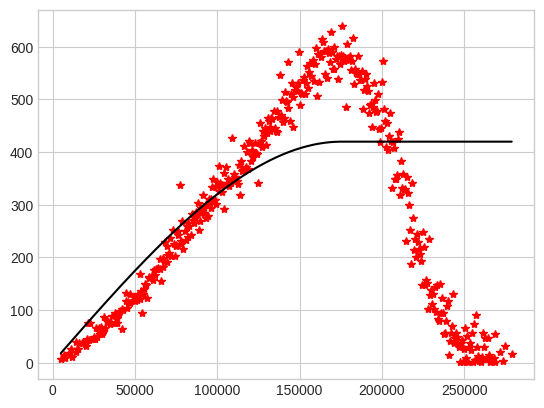

In [48]:
mpl.style.use('seaborn-v0_8-whitegrid')
OK1 = OrdinaryKriging(dff.latitude,dff.longitude,dff.value, variogram_model='spherical', nlags=450,
                    enable_plotting=True,
                    coordinates_type='euclidean')

In [49]:
irradiance1, ss1 = OK1.execute('points', Xi, Yi) # z la radiacion y ss la varianza

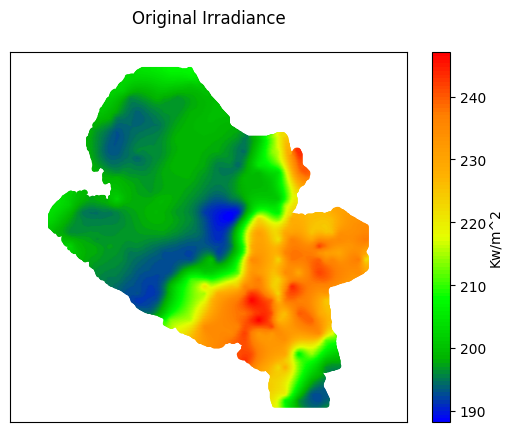

In [50]:
draw_map(Xi,Yi,irradiance1,"Original Irradiance","","Kw/m^2",True)

# Kriging Predicted

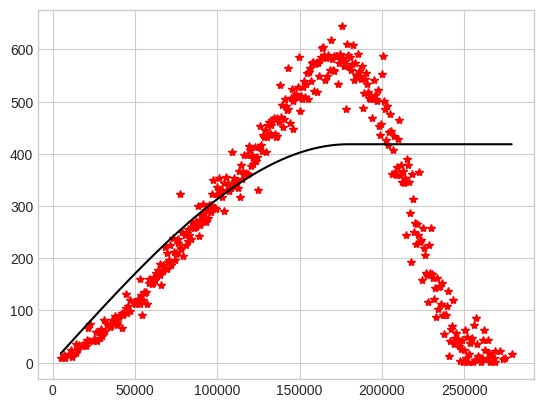

In [51]:
mpl.style.use('seaborn-v0_8-whitegrid')
OK2 = OrdinaryKriging(dff.latitude,dff.longitude,yp, variogram_model='spherical', nlags=450,
                    enable_plotting=True,
                    coordinates_type='euclidean')

In [52]:
irradiance2, ss2 = OK2.execute('points', Xi, Yi) # z la radiacion y ss la varianza

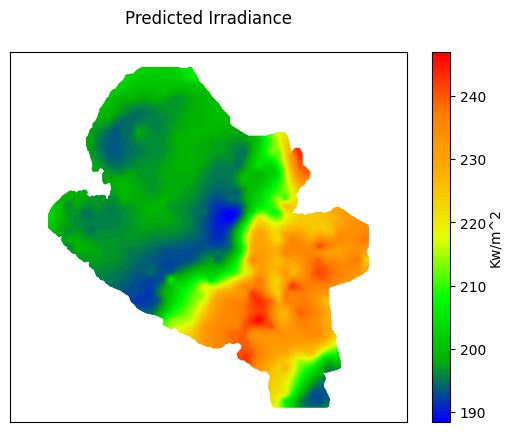

In [53]:
draw_map(Xi,Yi,irradiance2,"Predicted Irradiance","","Kw/m^2",True)

## Compare maps

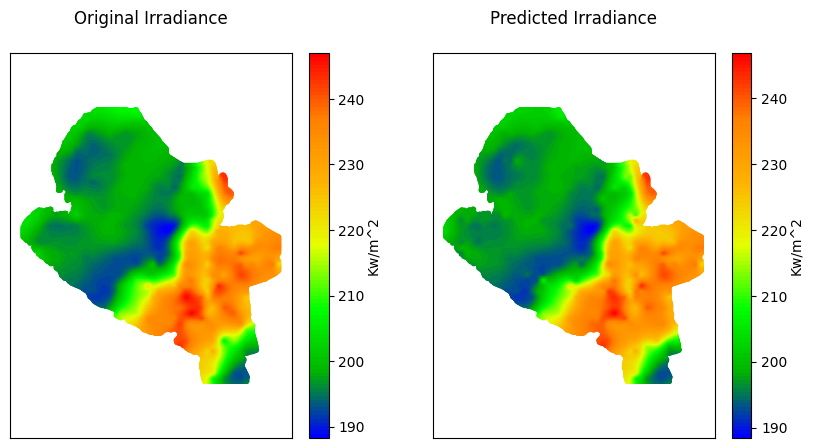

In [54]:
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
draw_map(Xi,Yi,irradiance1,"Original Irradiance","","Kw/m^2")
plt.subplot(1,2,2)
draw_map(Xi,Yi,irradiance2,"Predicted Irradiance","","Kw/m^2")
plt.show()

# Convert to image

In [55]:
from matplotlib.colors import LinearSegmentedColormap, Normalize

In [56]:
def getcolormap(zrk):
  #Cambiar por los colores del estudio realizado
  colors = [(0, 0, 1), (0, 0.7, 0),(0, 1, 0),(0.9,1,0),(1,0.7,0),(1, 0.5, 0),(1, 0, 0) ]
  cmap_name = 'my_list'
  cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=100)
  norm = Normalize(vmin=irradiance_min,vmax=irradiance_max)
  return cm(norm(zrk))

In [57]:
ymin=Yi.min()
ymax=Yi.max()
xmin=Xi.min()
xmax=Xi.max()

irradiance_min=min(irradiance2)
irradiance_max=max(irradiance2)
resolution=40

In [58]:
mycolors=getcolormap(irradiance2)
mycolors.shape

(109747, 4)

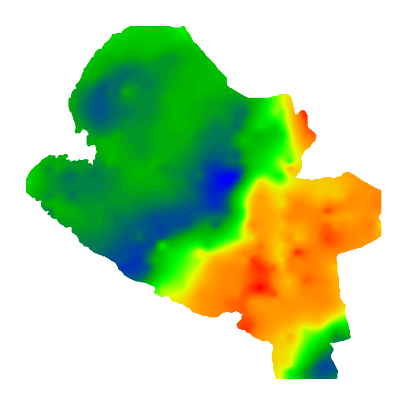

In [59]:
#figsize
plt.figure(figsize=(5,5))
#axis none
plt.axis('off')
plt.scatter(Xi,Yi,1,color=mycolors)

# Generate Raster

In [60]:
x_u=np.unique(Xi)
y_u=np.unique(Yi)

x_u=np.sort(x_u)
y_u=np.sort(y_u)
dif_x=np.diff(x_u)
dif_y=np.diff(y_u)

min_dif_x=np.min(dif_x)
min_dif_y=np.min(dif_y)

print(min_dif_x,min_dif_y)

523.1625835187733 556.2360801781178


In [61]:
Xi.shape, Yi.shape

((109747,), (109747,))

In [62]:
dfnar['red']=mycolors[:,0]
dfnar['green']=mycolors[:,1]
dfnar['blue']=mycolors[:,2]
dfnar['alpha']=mycolors[:,3]

In [63]:
def get_images(df,max_x,min_x,max_y,min_y,min_dif_x,min_dif_y):
  rows = int(np.ceil((max_y - min_y) / min_dif_y)) + 1
  cols = int(np.ceil((max_x - min_x) / min_dif_x)) + 1
  matrix_b1 = np.zeros((cols, rows))
  matrix_b2 = np.zeros((cols, rows))
  matrix_b3 = np.zeros((cols, rows))
  matrix_b4 = np.zeros((cols, rows))


  # Llenar la matriz con los valores de irradiancia
  for index, row in df.iterrows():
      lat_index = int(np.floor((row['lat'] - min_x) / min_dif_x))
      lon_index = int(np.floor((max_y-row['lon']) / min_dif_y))
      if 0 <= lat_index < rows and 0 <= lon_index < cols:
        matrix_b1[lon_index, lat_index] = row['red']
        matrix_b2[lon_index, lat_index] = row['green']
        matrix_b3[lon_index, lat_index] = row['blue']
        matrix_b4[lon_index, lat_index] = 0.6


  raster = np.stack((matrix_b1, matrix_b2, matrix_b3, matrix_b4), axis=-1)

  return (raster*255).astype(np.uint8)

In [64]:
raster_narino=get_images(dfnar,xmax,xmin,ymax,ymin,min_dif_x,min_dif_y)
raster_narino[:,:,0:3].shape

(451, 451, 3)

In [65]:
#green chanel
raster_narino[:,:,0:3].min(),raster_narino[:,:,0:3].max()

(np.uint8(0), np.uint8(255))

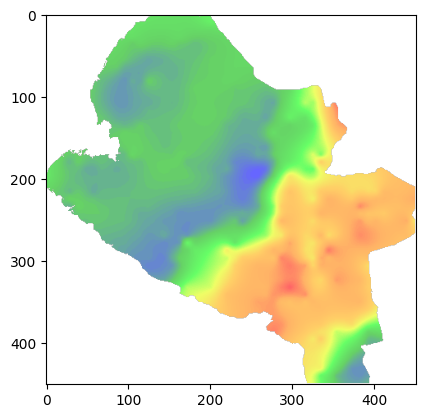

In [66]:
# Se comprueba que la imagen es correcta
plt.imshow(raster_narino[:,:,:])

In [67]:
raster_narino.shape

(451, 451, 4)

In [68]:
path

'/content/drive/MyDrive/Clase espejo/Conferencia UDENAR/narino/'

# Grabación de la imagen en png

In [70]:
#save raster_narino
#save raster_narino
from skimage import io
import numpy as np
path_image='/content/drive/MyDrive/Clase espejo/Conferencia UDENAR/ImagenLandsat/'

# Convert raster_narino to uint8 before saving
raster_narino_uint8 = raster_narino.astype(np.uint8)

io.imsave(path_image+'raster_narino_forecasting.png', raster_narino_uint8)


# Covertir a Geotif

In [71]:
#!/usr/bin/env python
from skimage import io
from osgeo import gdal
from osgeo import osr
import numpy as np
import os, sys

#  Initialize the Image Size 3857 metros 4326 angulos
def saveGeotiffImage(raster,name,projection=3857):
  image_size = raster.shape

  print(image_size)




  # set geotransform
  nx = image_size[0]
  ny = image_size[1]

  xres = (xmax - xmin) / float(nx)
  yres = (ymax - ymin) / float(ny)
  geotransform = (xmin, xres, 0, ymax, 0, -yres)

  # create the 3-band raster file
  dst_ds = gdal.GetDriverByName('GTiff').Create(path_image+'4B'+str(projection)+name+'.tif', ny, nx, 4, gdal.GDT_Byte)
  print("gdal getdriver at",path_image)
  dst_ds.SetGeoTransform(geotransform)    # specify coords
  srs = osr.SpatialReference()            # establish encoding
  srs.ImportFromEPSG(projection)                # WGS84 lat/long
  dst_ds.SetProjection(srs.ExportToWkt()) # export coords to file
  print("set projection",projection)
  dst_ds.GetRasterBand(1).WriteArray(raster[:,:,0])   # write r-band to the raster
  dst_ds.GetRasterBand(2).WriteArray(raster[:,:,1])   # write g-band to the raster
  dst_ds.GetRasterBand(3).WriteArray(raster[:,:,2])   # write b-band to the raster
  dst_ds.GetRasterBand(4).WriteArray(raster[:,:,3])   # write b-band to the raster
  print("write array 4 bands")
  dst_ds.FlushCache()                     # write to disk
  print("Write disk")
  dst_ds = None
  print("close file")


def reproyectar_tif_a_wgs84(input_path, output_path):
    """
    Reproyecta un archivo TIFF (por ejemplo, de EPSG:3857) a WGS84 (EPSG:4326).

    Args:
        input_path (str): Ruta al archivo GeoTIFF de entrada.
        output_path (str): Ruta para guardar el archivo GeoTIFF de salida reproyectado.
    """
    # 1. Definir el Sistema de Referencia de Coordenadas (SRS) de destino
    # 'EPSG:4326' es el WGS84, estándar para Google Earth/Maps.
    target_srs = 'EPSG:4326'

    # 2. Ejecutar la reproyección usando gdal.Warp()
    try:
        gdal.Warp(
            destNameOrDestDS=output_path,  # Nombre del archivo de salida
            srcDSOrSrcDSTab=input_path,    # Nombre del archivo de entrada
            dstSRS=target_srs,             # El SRS de destino
            resampleAlg=gdal.GRA_Bilinear # Algoritmo de remuestreo (Bilinear es un buen balance)
        )
        print(f"Reproyección completada. Archivo guardado en: {output_path}")
    except Exception as e:
        print(f"Ocurrió un error durante la reproyección: {e}")



def convertir_tif_a_kmz(input_tif_path, output_kmz_path):
    """
    Convierte un GeoTIFF (en EPSG:4326) a un archivo KMZ, pasando
    todas las opciones de creación y traducción correctamente como 'options'.
    """

    # 1. Definir las Opciones de Traducción y Creación
    # Se recomienda usar una lista de strings que imitan el comando de línea:
    opciones_gdal = [
        # Opciones de creación para el driver KMLSUPERSWITCH:
        '-co', 'FORMAT=KMZ',
        # Opción de traducción: Asegura que el archivo de entrada se trata como 4326.
        # Esto soluciona el error que estabas viendo.
        '-a_srs', 'EPSG:4326',
    ]

    try:
        gdal.Translate(
            destName=output_kmz_path,
            srcDS=input_tif_path,
            format='KMLSUPERSWITCH',
            options=opciones_gdal          # <-- ¡Cambio Clave! Pasa la lista de opciones aquí.
        )
        print(f"Conversión a KMZ completada. Archivo guardado en: {output_kmz_path}")
    except Exception as e:
        # Aunque el error 'a_srs' ya debería estar solucionado,
        # mantenemos la captura por si surge otro.
        print(f"Ocurrió un error durante la conversión a KMZ: {e}")





# La proyección 3857 es una proyección en metros

In [72]:
saveGeotiffImage(raster_narino_uint8,"Forecasting")

(451, 451, 4)


/usr/local/lib/python3.13/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


gdal getdriver at /content/drive/MyDrive/Clase espejo/Conferencia UDENAR/ImagenLandsat/
set projection 3857
write array 4 bands
Write disk
close file


https://app.geotiff.io/mean

# Reproyección tif

# La proyección 4326 es en ángulos

In [73]:
archivo_entrada=path_image+'4B3857Forecasting.tif'
archivo_salida_4326=path_image+'4B4326Forecasting.tif'
reproyectar_tif_a_wgs84(archivo_entrada, archivo_salida_4326)

Reproyección completada. Archivo guardado en: /content/drive/MyDrive/Clase espejo/Conferencia UDENAR/ImagenLandsat/4B4326Forecasting.tif


# Conversión KMZ

<a href='https://mygeodata.cloud/conversion'>Pulse aquí si no genera el kmz</a>

In [74]:
archivo_kmz=path_image+'4B4326Forecasting.kmz'
convertir_tif_a_kmz(archivo_salida_4326, archivo_kmz)

Conversión a KMZ completada. Archivo guardado en: /content/drive/MyDrive/Clase espejo/Conferencia UDENAR/ImagenLandsat/4B4326Forecasting.kmz


# KMZ comand line

In [75]:
!apt-get install gdal-bin

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  python3-gdal python3-numpy
Suggested packages:
  libgdal-grass python-numpy-doc python3-dev python3-pytest
The following NEW packages will be installed:
  gdal-bin python3-gdal python3-numpy
0 upgraded, 3 newly installed, 0 to remove and 1 not upgraded.
Need to get 5,168 kB of archives.
After this operation, 25.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 python3-numpy amd64 1:1.21.5-1ubuntu22.04.1 [3,467 kB]
Get:2 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 python3-gdal amd64 3.8.4+dfsg-1~jammy0 [1,095 kB]
Get:3 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 gdal-bin amd64 3.8.4+dfsg-1~jammy0 [605 kB]
Fetched 5,168 kB in 2s (2,951 kB/s)
Selecting previously unselected package python3-numpy.
(Reading database ... 118419 file

In [76]:
import subprocess
import os
import zipfile
from osgeo import gdal, osr

def reproyectar_y_crear_kmz_manual(input_tif_3857, output_kmz_name):
    """
    Reproyecta GeoTIFF y crea el archivo KMZ, generando el KML manualmente
    para evitar errores de drivers GDAL en entornos limitados como Colab.
    """

    # --- Archivos Intermedios ---
    tif_4326 = "temp_4326.tif"
    png_img = "temp_raster.png"
    kml_file = "temp_metadata.kml"

    print(f"Iniciando el procesamiento para: {input_tif_3857}")

    # 1. REPROYECCIÓN a WGS84 (EPSG:4326)
    print("\n--- 1. Reproyectando a EPSG:4326 ---")
    try:
        gdal.Warp(
            destNameOrDestDS=tif_4326,
            srcDSOrSrcDSTab=input_tif_3857,
            dstSRS='EPSG:4326',
            resampleAlg=gdal.GRA_Bilinear
        )
        print(f"Reproyección exitosa a: {tif_4326}")
    except Exception as e:
        print(f"ERROR en Reproyección (gdal.Warp): {e}")
        return None

    # 2. GENERACIÓN de PNG (Ráster)
    print("\n--- 2. Generando PNG (Ráster) ---")
    comando_png = ['gdal_translate', '-of', 'PNG', tif_4326, png_img]
    try:
        subprocess.run(comando_png, check=True, capture_output=True, text=True)
        print(f"Imagen PNG generada: {png_img}")
    except subprocess.CalledProcessError as e:
        print(f"ERROR al generar PNG (gdal_translate): {e.stderr}")
        return None

    # 3. EXTRACCIÓN de Coordenadas
    print("\n--- 3. Extrayendo Coordenadas ---")
    try:
        ds = gdal.Open(tif_4326)
        gt = ds.GetGeoTransform()

        # Calcular los límites (bounding box) en Lat/Lon (EPSG:4326)
        width = ds.RasterXSize
        height = ds.RasterYSize

        # Coordenadas: [Longitud Superior Izquierda, tamaño de píxel X, rotación, Latitud Superior Izquierda, rotación, tamaño de píxel Y (negativo)]

        # Longitud y Latitud de las esquinas
        lon_min = gt[0]
        lat_max = gt[3]
        lon_max = gt[0] + width * gt[1]
        lat_min = gt[3] + height * gt[5]

        ds = None # Cerrar el dataset
        print(f"Bounding Box extraído: ({lon_min:.4f}, {lat_min:.4f}) a ({lon_max:.4f}, {lat_max:.4f})")
    except Exception as e:
        print(f"ERROR al extraer coordenadas: {e}")
        return None

    # 4. GENERACIÓN MANUAL del KML
    print("\n--- 4. Generando KML Manualmente ---")
    try:
        kml_content = f"""<?xml version="1.0" encoding="UTF-8"?>
<kml xmlns="http://www.opengis.net/kml/2.2" xmlns:gx="http://www.google.com/kml/ext/2.2" xmlns:kml="http://www.opengis.net/kml/2.2" xmlns:atom="http://www.w3.org/2005/Atom">
  <Folder>
    <name>{os.path.basename(output_kmz_name).replace(".kmz", "")}</name>
    <GroundOverlay>
      <name>Imagen Georreferenciada</name>
      <Icon>
        <href>{os.path.basename(png_img)}</href>
      </Icon>
      <LatLonBox>
        <north>{lat_max}</north>
        <south>{lat_min}</south>
        <east>{lon_max}</east>
        <west>{lon_min}</west>
      </LatLonBox>
    </GroundOverlay>
  </Folder>
</kml>
"""
        with open(kml_file, 'w') as f:
            f.write(kml_content)
        print(f"Archivo KML generado con éxito: {kml_file}")
    except Exception as e:
        print(f"ERROR al escribir KML: {e}")
        return None

    # 5. COMPRESIÓN de KML y PNG en KMZ
    print("\n--- 5. Comprimiendo a KMZ (ZIP) ---")
    try:
        with zipfile.ZipFile(output_kmz_name, 'w') as zf:
            zf.write(kml_file, os.path.basename(kml_file))
            zf.write(png_img, os.path.basename(png_img))
        print(f"Archivo KMZ final creado con éxito: {output_kmz_name}")
    except Exception as e:
        print(f"ERROR al crear el KMZ: {e}")
        return None

    # 6. Limpieza de archivos temporales
    for f in [tif_4326, png_img, kml_file]:
        if os.path.exists(f):
            os.remove(f)

    return output_kmz_name



In [77]:
kmz_creado = reproyectar_y_crear_kmz_manual(archivo_entrada, archivo_kmz)

if kmz_creado:
     from google.colab import files
     files.download(kmz_creado)

Iniciando el procesamiento para: /content/drive/MyDrive/Clase espejo/Conferencia UDENAR/ImagenLandsat/4B3857Forecasting.tif

--- 1. Reproyectando a EPSG:4326 ---
Reproyección exitosa a: temp_4326.tif

--- 2. Generando PNG (Ráster) ---
Imagen PNG generada: temp_raster.png

--- 3. Extrayendo Coordenadas ---
Bounding Box extraído: (-78.9606, 0.4019) a (-76.8508, 2.6468)

--- 4. Generando KML Manualmente ---
Archivo KML generado con éxito: temp_metadata.kml

--- 5. Comprimiendo a KMZ (ZIP) ---
Archivo KMZ final creado con éxito: /content/drive/MyDrive/Clase espejo/Conferencia UDENAR/ImagenLandsat/4B4326Forecasting.kmz


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#